# SAMS Loch Etive Secchi Depth and Sensing Secchi Disk
## Step 1: Load programmes

In [1]:
#Programes and functions
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import datetime
import scipy
from numpy import mean, absolute, median
from matplotlib import pyplot as plt
from scipy import interpolate
from scipy.optimize import curve_fit
from lmfit import Minimizer, Parameters, report_fit
from scipy.io import loadmat
import scipy.stats as stats
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import linecache
import re
from sklearn import linear_model, datasets
from sklearn.linear_model import LinearRegression
from scipy.signal import savgol_filter
from scipy.signal import medfilt
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import contextily as ctx
import geopandas as gpd
from pyproj import Transformer
    
# Supresses outputs when trying to "divide by zero" or "divide by NaN" or "treatment for floating-point overflow"
#np.seterr(divide='ignore', over='ignore', invalid='ignore');
np.seterr(all='ignore');

## Step 2: Definitons

In [2]:
# For extracting Metadata
def extract_metadata(file):
    def extract_line(index, float_=True):
        line = linecache.getline(file, index)
        nums = re.findall(r'-?\d+\.?\d*', line)
        return np.float_(nums) if float_ else nums
    SD = extract_line(1)
    FU = extract_line(2)
    pH = extract_line(3)
    SN = extract_line(4)
    lat = extract_line(5)
    lon = extract_line(6)
    # Fix date parsing
    date_line = linecache.getline(file, 7)
    date = re.findall(r'\d+', date_line)
    year, month, day = map(float, date[:3])
    print(f"Year = {year}\nMonth = {month}\nDay = {day}")
    print(f"Latitude = {lat[0]}° N\nLongitude = {lon[0]}° E")
    print(f"Zsd = {SD[0]} cm \nFU = {FU[0]}")
    return year, month, day, lat[0], lon[0], SD[0], FU[0]

# For extracting column name
def col(name):
    return df.loc[:, name].to_numpy()

# Convert time to seconds
def convert_time_to_sec(times):
    times_sec = []
    for t in times:
        h, m, s = map(int, t.split(':'))
        times_sec.append(h*3600 + m*60 + s)
    return np.array(times_sec)

# --- Regression Fitting Function --- Fits K in top 30 meters
def fit_k_profile(Y, X, threshold_low=2, threshold_high=8):
    mask = (Y > 0) & (X > threshold_low) & (X < threshold_high)
    X_fit, Y_fit = X[mask], np.log(Y[mask])
    model = LinearRegression().fit(X_fit.reshape(-1, 1), Y_fit.reshape(-1, 1))

    # Stats
    r_val = stats.pearsonr(X_fit, Y_fit)[0]
    N, p = len(X_fit), 2
    X_design = np.column_stack((np.ones(N), X_fit))
    y_hat = model.predict(X_fit.reshape(-1, 1))
    residuals = Y_fit.reshape(-1, 1) - y_hat
    sigma_sq = (residuals.T @ residuals) / (N - p)
    var_b = np.linalg.inv(X_design.T @ X_design) * sigma_sq
    se = np.sqrt(np.diag(var_b))

    intercept = model.intercept_[0]
    slope = model.coef_[0][0]

    return intercept, -slope, se[0], se[1], r_val

# --- Fit Light Profiles ---
def fit_all_profiles(data_dict, depth_array):
    G, K, G_SE, K_SE, R = [], [], [], [], []
    for wl in WAVELENGTHS:
        g, k, g_se, k_se, r = fit_k_profile(data_dict[wl], depth_array)
        G.append(g); K.append(k)
        G_SE.append(g_se); K_SE.append(k_se)
        R.append(r)
    return np.array(G), np.array(K), np.array(G_SE), np.array(K_SE), np.array(R)

# ---- Read CNV files-----
def read_cnv(file):

    import pandas as pd

    with open(file, 'r', encoding='latin-1', errors='ignore') as f:
        lines = f.readlines()

    # -------------------------
    # find end of header safely
    # -------------------------
    start_idx = None
    for i, line in enumerate(lines):
        if "*END*" in line:
            start_idx = i + 1
            break

    if start_idx is None:
        raise ValueError(f"*END* not found in {file}")

    # -------------------------
    # read numeric data
    # -------------------------
    df = pd.read_csv(
        file,
        delim_whitespace=True,
        skiprows=start_idx,
        header=None,
        encoding='latin-1'
    )

    # -------------------------
    # parse column names
    # -------------------------
    col_names = {}

    for line in lines:
        if line.startswith("# name"):
            parts = line.split("=")
            idx = int(parts[0].split()[2])
            name = parts[1].split(":")[0].strip()
            col_names[idx] = name

    df.columns = [col_names[i] for i in range(len(df.columns))]

    return df

## Step 3: Secchi depth and Forel Ule data

In [3]:
Zd_RE5_260529 = [3.3,3.6,3.7]
FU_RE5_260529 = [18,15,15]
Zd_RE2_260529 = [3.0,2.9,3.0]
FU_RE2_260529 = [18,18,17]
Zd_RE3_260529 = [3.0,3.0,3.0]
FU_RE3_260529 = [17,17,16]
Zd_RE6_260529 = [5.1,3.9,4.6,5.2]
FU_RE6_260529 = [16,15,15,14]
Zd_RE5_260601 = [3.1,3.3,3.3,3.3]
FU_RE5_260601 = [18,19,18]
Zd_RE4_260601 = [2.9,2.9,2.75]
FU_RE4_260601 = [19,19,18]
Zd_RE6_260601 = [3.6,3.5,3.6,3.5]
FU_RE6_260601 = [18,18,18,17]
Zd_RE7_260601 = [3.2,4.1,4.0,4.0,4.4]
FU_RE7_260601 = [18,15,18,16,15]
Zd_RE7_5_260601 = [4.3,4.3,4.6,4.2]
FU_RE7_5_260601 = [18,15,15,16]
Zd_RE9_260601 = [4.1,5.3,4.7,4.5,5.]
FU_RE9_260601 = [15,15,15,15,14]
Zd_RE8_260601 = [6.3,6.3,6.2,6.1]
FU_RE8_260601 = [8,8,10,8]

Zd_data = {
    'RE5_260529': Zd_RE5_260529,
    'RE2_260529': Zd_RE2_260529,
    'RE3_260529': Zd_RE3_260529,
    'RE6_260529': Zd_RE6_260529,
    'RE5_260601': Zd_RE5_260601,
    'RE4_260601': Zd_RE4_260601,
    'RE6_260601': Zd_RE6_260601,
    'RE7_260601': Zd_RE7_260601,
    'RE7_5_260601': Zd_RE7_5_260601,
    'RE9_260601': Zd_RE9_260601,
    'RE8_260601': Zd_RE8_260601,
}

FU_data = {
    'RE5_260529': FU_RE5_260529,
    'RE2_260529': FU_RE2_260529,
    'RE3_260529': FU_RE3_260529,
    'RE6_260529': FU_RE6_260529,
    'RE5_260601': FU_RE5_260601,
    'RE4_260601': FU_RE4_260601,
    'RE6_260601': FU_RE6_260601,
    'RE7_260601': FU_RE7_260601,
    'RE7_5_260601': FU_RE7_5_260601,
    'RE9_260601': FU_RE9_260601,
    'RE8_260601': FU_RE8_260601,
}

stations = []
Zd_mean = []
Zd_std = []
FU_mean = []
FU_std = []

for station, values in Zd_data.items():
    stations.append(station)
    Zd_mean.append(np.mean(values))
    Zd_std.append(np.std(values, ddof=1))  # sample std

for station, values in FU_data.items():
    stations.append(station)
    FU_mean.append(np.mean(values))
    FU_std.append(np.std(values, ddof=1))  # sample std

Zd_mean = np.array(Zd_mean)
Zd_std = np.array(Zd_std)

print(stations)
print(Zd_mean)
print(Zd_std)
print(FU_mean)
print(FU_std)

['RE5_260529', 'RE2_260529', 'RE3_260529', 'RE6_260529', 'RE5_260601', 'RE4_260601', 'RE6_260601', 'RE7_260601', 'RE7_5_260601', 'RE9_260601', 'RE8_260601', 'RE5_260529', 'RE2_260529', 'RE3_260529', 'RE6_260529', 'RE5_260601', 'RE4_260601', 'RE6_260601', 'RE7_260601', 'RE7_5_260601', 'RE9_260601', 'RE8_260601']
[3.53333333 2.96666667 3.         4.7        3.25       2.85
 3.55       3.94       4.35       4.72       6.225     ]
[0.2081666  0.05773503 0.         0.59441848 0.1        0.08660254
 0.05773503 0.44497191 0.17320508 0.46043458 0.09574271]
[16.0, 17.666666666666668, 16.666666666666668, 15.0, 18.333333333333332, 18.666666666666668, 17.75, 16.4, 16.0, 14.8, 8.5]
[1.7320508075688772, 0.5773502691896258, 0.5773502691896258, 0.816496580927726, 0.5773502691896258, 0.5773502691896258, 0.5, 1.5165750888103102, 1.4142135623730951, 0.4472135954999579, 1.0]


## Step 4: Process Sensing Secchi Disk data

In [4]:
## SSD
Folder = 'SSD/'
File_1= ['26060106_A012_RIG_RE8.txt','26060105_A012_RIG_RE9.txt','26060104_A012_RIG_RE7_5.txt',\
         '26060103_A012_RIG_RE7.txt','26052905_A012_RIG_RE6.txt','26060102_A012_RIG_RE6.txt',\
         '26052901_A012_RIG_RE5.txt','26060100_A012_RIG_RE5.txt','26060101_A012_RIG_RE4.txt',\
         '26052904_A012_RIG_RE3.txt','26052903_A012_RIG_RE2.txt']
WAVELENGTHS = [405, 425, 450, 475, 515, 550, 555, 600, 640, 690, 745]
INDEX_DAY   = [1,1,1,1,0,1,0,1,1,0,0]

## Stations
INDEX = ['RE08_010626','RE09_010626','RE07_5_010626','RE07_010626','RE06_290526','RE06_010626',\
        'RE05_290526','RE05_010626','RE04_010626','RE03_290526','RE02_290526']

# Wavelengths of A012
LIGHT_LABELS = [f"{wl}nm" for wl in WAVELENGTHS]

for i in range(len(File_1)):
    print(i)
    # Extract metadata
    year, month, day, lat, lon, SD, FU = extract_metadata(Folder+File_1[i])
    # --- Load Profile Data ---
    df = pd.read_csv(Folder+File_1[i], header=7)
    Time_SS         = col('Time (UTC)')
    Pressure_SS     = col(' Pressure (mbar) MS5803')
    Temp_MS5803_SS  = col(' Temp (deg C) MS5803')
    Temp_10KTHERM_SS= col(' Temp (deg C) 10KTHERM')
    Temp_TH_SS      = col(' Temp (deg C) TMP117')
    if INDEX_DAY[i] == 0:
            # Light data
            ED = {wl: col(f' ED {wl}nm') for wl in WAVELENGTHS}
            EU = {wl: col(f' EU {wl}nm') for wl in WAVELENGTHS}
            ED['Clear']     = col(' ED Clear')
            EU['Clear']     = col(' EU Clear')
    else:
            GAINS_ED_SS     = col(' ED GAINS')
            GAINS_EU_SS     = col(' EU GAINS')
            # Light data, correct for gains
            ED = {wl: col(f' ED {wl}nm') / GAINS_ED_SS for wl in WAVELENGTHS}
            EU = {wl: col(f' EU {wl}nm') / GAINS_EU_SS for wl in WAVELENGTHS}
            ED['Clear'] = col(' ED Clear') / GAINS_ED_SS
            EU['Clear'] = col(' EU Clear') / GAINS_EU_SS
    # --- Time & Depth Processing ---
    ATMOS_P = np.median(Pressure_SS[:5])
    Depth_SS = (Pressure_SS - ATMOS_P) / 100.0
    Depth_SS_TU = Depth_SS + 0.007
    Depth_SS_LD = Depth_SS - 0.03
    DATA_SEC = convert_time_to_sec(Time_SS)
    DATA_SEC0 = DATA_SEC - DATA_SEC[0]
    # Fits a Beer lambert law to the data
    GD_spect, KD_spect, GD_spect_SE, KD_spect_SE, RD_spect = fit_all_profiles(ED, Depth_SS_LD)
    GD_CLEAR, KD_CLEAR, GD_CLEAR_SE, KD_CLEAR_SE, RD_CLEAR = fit_k_profile(ED['Clear'],Depth_SS_LD)
    
    ##Station number
    exec('Time_SS_'+INDEX[i]+'=Time_SS')
    exec('ED_'+INDEX[i]+'=ED')
    exec('EU_'+INDEX[i]+'=EU')
    exec('Temp_TH_SS_'+INDEX[i]+'=Temp_TH_SS') 
    exec('KD_spect_'+INDEX[i]+'=KD_spect')
    exec('GD_spect_'+INDEX[i]+'=GD_spect')    
    exec('KD_spect_SE_'+INDEX[i]+'=KD_spect_SE')
    exec('GD_spect_SE_'+INDEX[i]+'=GD_spect_SE') 
    exec('KD_CLEAR_'+INDEX[i]+'=KD_CLEAR')
    exec('GD_CLEAR_'+INDEX[i]+'=GD_CLEAR')
    exec('KD_CLEAR_SE_'+INDEX[i]+'=KD_CLEAR_SE')
    exec('GD_CLEAR_SE_'+INDEX[i]+'=GD_CLEAR_SE') 
    exec('Depth_SS_TU_'+INDEX[i]+'=Depth_SS_TU') 
    exec('Depth_SS_LD_'+INDEX[i]+'=Depth_SS_LD') 
    exec('DATA_SEC0_'+INDEX[i]+'=DATA_SEC0') 
    exec('SD_'+INDEX[i]+'=SD') 
    exec('FU_'+INDEX[i]+'=FU') 
    exec('lat_'+INDEX[i]+'=lat') 
    exec('lon_'+INDEX[i]+'=lon') 
    

# -----------------------------
# 1. Combine station data
# -----------------------------
lon = np.array([
    lon_RE05_290526, lon_RE02_290526, lon_RE03_290526, lon_RE06_290526,
    lon_RE05_010626, lon_RE04_010626, lon_RE06_010626, lon_RE07_010626,
    lon_RE07_5_010626, lon_RE09_010626, lon_RE08_010626
])

Dates = np.array(['29-05-2026', '29-05-2026', '29-05-2026', '29-05-2026',
    '01-06-2026', '01-06-2026', '01-06-2026', '01-06-2026',
    '01-06-2026', '01-06-2026', '01-06-2026'
])

# Kd PAR
kd = np.array([
    KD_CLEAR_RE05_290526, KD_CLEAR_RE02_290526, KD_CLEAR_RE03_290526,
    KD_CLEAR_RE06_290526, KD_CLEAR_RE05_010626, KD_CLEAR_RE04_010626,
    KD_CLEAR_RE06_010626, KD_CLEAR_RE07_010626, KD_CLEAR_RE07_5_010626,
    KD_CLEAR_RE09_010626, KD_CLEAR_RE08_010626
])

# Kd PAR Standard Error
kd_se = np.array([
    KD_CLEAR_SE_RE05_290526, KD_CLEAR_SE_RE02_290526, KD_CLEAR_SE_RE03_290526,
    KD_CLEAR_SE_RE06_290526, KD_CLEAR_SE_RE05_010626, KD_CLEAR_SE_RE04_010626,
    KD_CLEAR_SE_RE06_010626, KD_CLEAR_SE_RE07_010626, KD_CLEAR_SE_RE07_5_010626,
    KD_CLEAR_SE_RE09_010626, KD_CLEAR_SE_RE08_010626
])


0
Year = 2026.0
Month = 6.0
Day = 1.0
Latitude = 56.46103° N
Longitude = -5.44666° E
Zsd = 623.0 cm 
FU = 9.0
1
Year = 2026.0
Month = 6.0
Day = 1.0
Latitude = 56.46399° N
Longitude = -5.34077° E
Zsd = 472.0 cm 
FU = 15.0
2
Year = 2026.0
Month = 6.0
Day = 1.0
Latitude = 56.45936° N
Longitude = -5.31473° E
Zsd = 435.0 cm 
FU = 16.0
3
Year = 2026.0
Month = 6.0
Day = 1.0
Latitude = 56.45682° N
Longitude = -5.28251° E
Zsd = 394.0 cm 
FU = 16.0
4
Year = 2026.0
Month = 5.0
Day = 29.0
Latitude = 56.44829° N
Longitude = -5.24618° E
Zsd = 470.0 cm 
FU = 15.0
5
Year = 2026.0
Month = 6.0
Day = 1.0
Latitude = 56.4483° N
Longitude = -5.24634° E
Zsd = 355.0 cm 
FU = 18.0
6
Year = 2026.0
Month = 5.0
Day = 29.0
Latitude = 56.45444° N
Longitude = -5.19068° E
Zsd = 353.0 cm 
FU = 16.0
7
Year = 2026.0
Month = 6.0
Day = 1.0
Latitude = 56.45599° N
Longitude = -5.18784° E
Zsd = 325.0 cm 
FU = 18.0
8
Year = 2026.0
Month = 6.0
Day = 1.0
Latitude = 56.46843° N
Longitude = -5.16756° E
Zsd = 285.0 cm 
FU = 19.0
9

## Step 5: Plot Map of area

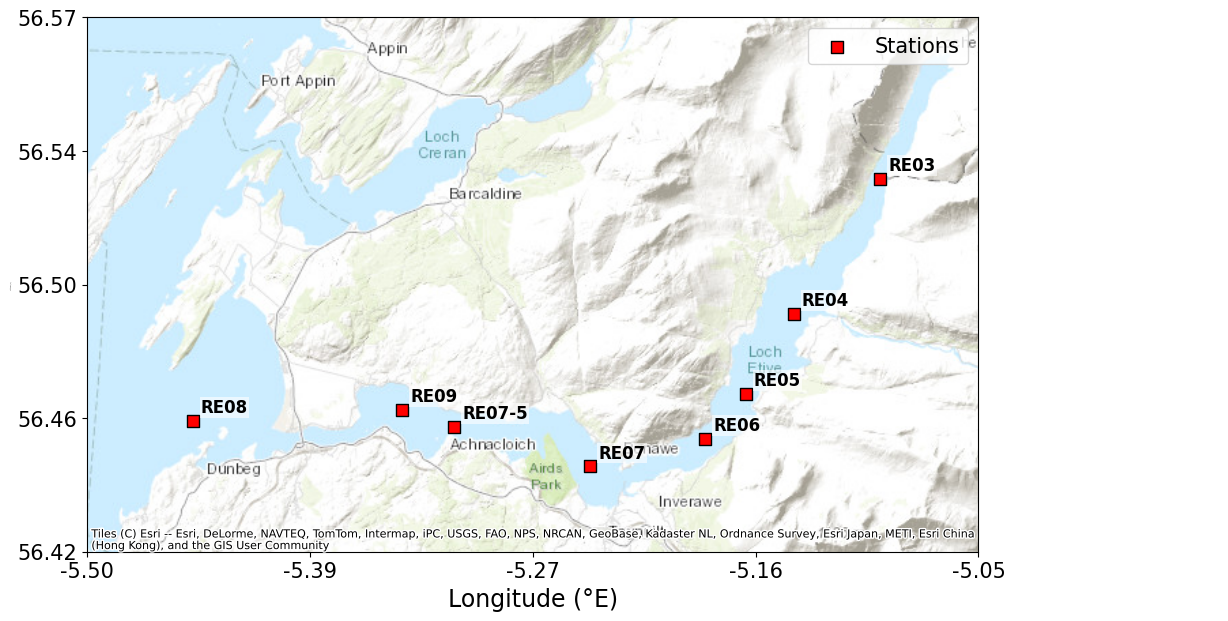

In [5]:
# ----------------------------
# Station coordinates
# ----------------------------
Labels_map = ['RE08','RE09','RE07-5','RE07','RE06', 'RE05','RE04','RE03', 'RE02']
Station_lon = [lon_RE08_010626, lon_RE09_010626, lon_RE07_5_010626, lon_RE07_010626, lon_RE06_290526, lon_RE05_010626,\
              lon_RE04_010626,lon_RE03_290526,lon_RE02_290526]
Station_lat = [lat_RE08_010626, lat_RE09_010626, lat_RE07_5_010626, lat_RE07_010626, lat_RE06_290526, lat_RE05_010626,\
              lat_RE04_010626,lat_RE03_290526,lat_RE02_290526]

# ----------------------------
# Area limits
# ----------------------------
Max_lon = -5.05
Min_lon = -5.5
Max_lat = 56.573326
Min_lat = 56.424452

# ----------------------------
# Create GeoDataFrame
# ----------------------------
df = pd.DataFrame({
    'Longitude': Station_lon,
    'Latitude': Station_lat
})

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.Longitude, df.Latitude),
    crs='EPSG:4326'
)

# Convert to Web Mercator for Contextily
gdf_web = gdf.to_crs(epsg=3857)

# Convert map boundaries to Web Mercator
bbox = gpd.GeoSeries.from_xy(
    [Min_lon, Max_lon],
    [Min_lat, Max_lat],
    crs='EPSG:4326'
).to_crs(epsg=3857)

# ----------------------------
# Create figure
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 12))

# Plot stations
gdf_web.plot(
    ax=ax,
    color='red',
    marker='s',
    edgecolor='black',
    markersize=75,
    label='Stations'
)

# Add labels next to each point
for x, y, label in zip(gdf_web.geometry.x, gdf_web.geometry.y, Labels_map):
    ax.annotate(
        text=label,
        xy=(x, y),
        xytext=(6, 6),          # offset in points (adjust as needed)
        textcoords='offset points',
        fontsize=12,
        color='black',
        weight='bold',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)
    )

# Set map extent
xmin = bbox.geometry.x.min()
xmax = bbox.geometry.x.max()
ymin = bbox.geometry.y.min()
ymax = bbox.geometry.y.max()

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Add OpenStreetMap basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldTopoMap
)

# Formatting
ax.legend(fontsize=15)
ax.tick_params(axis='both', labelsize=15)

# Transformer from Web Mercator back to WGS84
transformer = Transformer.from_crs(
    "EPSG:3857",
    "EPSG:4326",
    always_xy=True
)

# Number of ticks
n_ticks = 5

# Current map limits
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

# Create tick locations in Web Mercator coordinates
xticks = np.linspace(xmin, xmax, n_ticks)
yticks = np.linspace(ymin, ymax, n_ticks)

# Convert ticks back to lon/lat
lon_labels = [
    f"{transformer.transform(x, ymin)[0]:.2f}"
    for x in xticks
]

lat_labels = [
    f"{transformer.transform(xmin, y)[1]:.2f}"
    for y in yticks
]

# Apply ticks and labels
ax.set_xticks(xticks)
ax.set_xticklabels(lon_labels)

ax.set_yticks(yticks)
ax.set_yticklabels(lat_labels)

ax.set_xlabel('Longitude (°E)', fontsize=17)
ax.set_ylabel('Latitude (°N)', fontsize=1)

plt.tight_layout()

# Save figure
fig.savefig(
    'Figure_Map_Etive_Stations.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Step 6: Plot Secchi depth and FU data

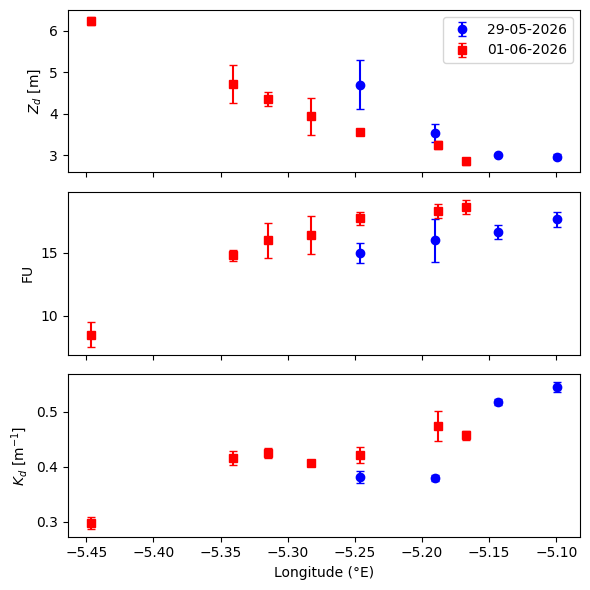

In [6]:
# -----------------------------
# 3-panel plot (no map)
# -----------------------------

date1 = '29-05-2026'
date2 = '01-06-2026'

mask1 = Dates == date1
mask2 = Dates == date2

FU_mean = np.array(FU_mean)
FU_std = np.array(FU_std)

fig, ax = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

# -----------------------------
# Z_d
# -----------------------------
ax[0].errorbar(
    lon[mask1], Zd_mean[mask1], yerr=Zd_std[mask1],
    fmt='ob', capsize=3, label=date1
)
ax[0].errorbar(
    lon[mask2], Zd_mean[mask2], yerr=Zd_std[mask2],
    fmt='sr', capsize=3, label=date2
)
ax[0].set_ylabel(r"$Z_d$ [m]")
ax[0].legend()

# -----------------------------
# FU
# -----------------------------
ax[1].errorbar(
    lon[mask1], FU_mean[mask1], yerr=FU_std[mask1],
    fmt='ob', capsize=3
)
ax[1].errorbar(
    lon[mask2], FU_mean[mask2], yerr=FU_std[mask2],
    fmt='sr', capsize=3
)
ax[1].set_ylabel("FU")

# -----------------------------
# Kd
# -----------------------------
ax[2].errorbar(
    lon[mask1], kd[mask1], yerr=kd_se[mask1],
    fmt='ob', capsize=3
)
ax[2].errorbar(
    lon[mask2], kd[mask2], yerr=kd_se[mask2],
    fmt='sr', capsize=3
)
ax[2].set_ylabel(r"$K_d$ [m$^{-1}$]")
ax[2].set_xlabel("Longitude (°E)")


plt.tight_layout()
plt.show()

## Step 7: Plot Kd spectral

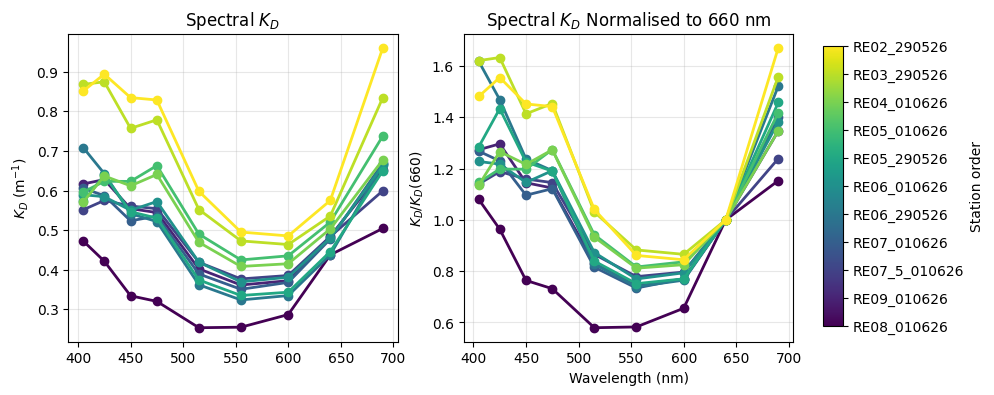

In [7]:
# WAVELENGTHS = np.array([415, 445, 480, 515, 555, 590, 630, 680])
WAVELENGTHS = np.array([405, 425, 450, 475, 515, 550, 555, 600, 640, 690, 745])


# Create colours according to station order
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=0, vmax=len(INDEX)-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4), sharex=True)

for i, station in enumerate(INDEX):

    kd = np.asarray(globals()[f'KD_spect_{station}'])
    
    remove_wl = [550, 745]
    mask = ~np.isin(WAVELENGTHS, remove_wl)
    WAVELENGTHS_f = np.array(WAVELENGTHS)[mask]
    kd = kd[mask]


    colour = cmap(norm(i))

    # Raw spectra
    ax1.plot(
        WAVELENGTHS_f,
        kd,
        '-o',
        color=colour,
        lw=2
    )

    # Normalise to nearest wavelength to 660 nm
    idx660 = np.argmin(np.abs(WAVELENGTHS_f - 660))
    kd_norm = kd / kd[idx660]

    ax2.plot(
        WAVELENGTHS_f,
        kd_norm,
        '-o',
        color=colour,
        lw=2
    )

# Formatting
ax1.set_ylabel(r'$K_D$ (m$^{-1}$)')
ax1.set_title('Spectral $K_D$')

ax2.set_ylabel(r'$K_D/K_D(660)$')
ax2.set_xlabel('Wavelength (nm)')
ax2.set_title('Spectral $K_D$ Normalised to 660 nm')

for ax in (ax1, ax2):
    ax.grid(alpha=0.3)

# Leave room on right for colorbar
fig.subplots_adjust(right=0.85)

# Create colorbar axis
cax = fig.add_axes([0.88, 0.15, 0.02, 0.7])  # [left, bottom, width, height]

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Station order')
cbar.set_ticks(range(len(INDEX)))
cbar.set_ticklabels(INDEX)

plt.show()